# 02 — Preprocessing: visualise & verify

Goal of this notebook:

1. Inspect `VietnameseTextCleaner` on representative comments.
2. Apply the pipeline to all of train, check side-effects.
3. Decide whether to remove Vietnamese stop-words for this task.
4. Fit + persist the BoW / TF-IDF vectorizers (delegated to `src.features`).
5. Verify a saved vectorizer can be reloaded and applied to new text.

After this notebook the project is ready for **Week 3 — ML baselines**.

## 1. Setup & Imports

In [1]:
import sys, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from configs.config import PATHS, COLUMNS, LABEL_MAP, LABEL_COLORS
from src.preprocess import VietnameseTextCleaner, batch_clean
from src.features   import (
    fit_vectorizers, transform_and_save,
    load_vectorizers, load_feature_matrix,
    VECTORIZER_DIR, PROCESSED_DIR,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 140)

TEXT, LABEL = COLUMNS['text'], COLUMNS['label']
RANDOM_STATE = 42
print('Project root :', ROOT)

Project root : /home/user/Graduation-Project


In [2]:
train = pd.read_csv(PATHS['raw_train'])
dev   = pd.read_csv(PATHS['raw_dev'])
test  = pd.read_csv(PATHS['raw_test'])
print('train:', train.shape, '| dev:', dev.shape, '| test:', test.shape)
train.head(2)

train: (24048, 2) | dev: (2672, 2) | test: (6680, 2)


,free_text,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]],0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :))),2


## 2. Before vs After — 20 stratified comments

10 CLEAN + 5 OFFENSIVE + 5 HATE, sampled with fixed seed.

In [3]:
cleaner = VietnameseTextCleaner()

sampled_parts = [
    train[train[LABEL] == 0].sample(10, random_state=RANDOM_STATE),
    train[train[LABEL] == 1].sample(5,  random_state=RANDOM_STATE),
    train[train[LABEL] == 2].sample(5,  random_state=RANDOM_STATE),
]
sample = pd.concat(sampled_parts).reset_index(drop=True)
sample['label_name'] = sample[LABEL].map(LABEL_MAP)
sample['cleaned']    = sample[TEXT].apply(cleaner.clean)

sample[['label_name', TEXT, 'cleaned']].rename(
    columns={TEXT: 'original'}
)

,label_name,original,cleaned
0,CLEAN,Đây hả?,đây hả
1,CLEAN,Ăn trộm ăn cắp cũng vừa phải thôi chứ 😠😠,ăn_trộm ăn_cắp cũng vừa_phải thôi chứ
2,CLEAN,"hỉ cần toàn dân ta đoàn kết, đồng lòng sẽ chiến thắng ! như dân tộc Việt Nam ta đã từng chiến thắng ! cố lên VN ơi",hỉ cần toàn dân ta đoàn_kết đồng_lòng sẽ chiến_thắng như dân_tộc việt_nam ta đã từng chiến_thắng cố lên vn ơi
3,CLEAN,Gửi mấy bé sống nhanh vs sống chậm,gửi mấy bé sống nhanh_vs sống chậm
4,CLEAN,Like đầu 🤣,like đầu
5,CLEAN,Chỉ được cái lôi thằng con ra câu donate là hay 😂. Tùng said: Chụp nhanh lên ông già,chỉ được cái lôi thằng con ra câu donate là hay tùng said chụp nhanh lên ông_già
6,CLEAN,Anh em đón Tết Corona thế nào rồi :)),anh_em đón tết corona thế_nào rồi
7,CLEAN,Mỗi ngày 10 cuộc gọi.chọc cho nó chửi.2 tuần nó chửi trào mẩu họng ra nó chết k cần giết nó cũng chêt,mỗi ngày 10 cuộc_gọi chọc cho nó chửi 2 tuần nó chửi_trào mẩu họng ra nó chết không cần giết nó cũng chêt
8,CLEAN,Nghe anh Độ nói tối nay lại off các ông ạ :)))),nghe anh độ nói tối nay lại off các ông ạ
9,CLEAN,Cố tỏ ra là mình ổn nhưng sâu bên trong nước mắt là biển rộng :'(,cố tỏ ra là mình ổn nhưng sâu bên trong nước_mắt là biển rộng


**Observations** (fill in after running):

* ✅ *Cases normalised well*: teencode (`ko → không`, `vl → vãi`), repeated chars (`ngonnnnn → ngon`), emoji removed, URLs stripped, casing normalised.
* ⚠️ *Edge cases to watch*:
  * Tokens that disappear after cleaning when the whole comment was emoji/punctuation only.
  * Profanity written with intentional misspelling (`đmm`, `cl`) – may not all be in `teencode.json` yet.
  * Multi-syllable Vietnamese words now joined with `_` (e.g. `lò_xo`). Downstream BoW treats them as one token, which is what we want.

## 3. Apply pipeline to the whole train split

In [4]:
train_clean = batch_clean(train[TEXT], cleaner=cleaner, desc='Cleaning train')
train['cleaned'] = train_clean.values

Cleaning train:   0%|          | 0/24048 [00:00<?, ?it/s]

/tmp/ipykernel_1363/4097757225.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['raw', 'cleaned'], patch_artist=True, showfliers=False)


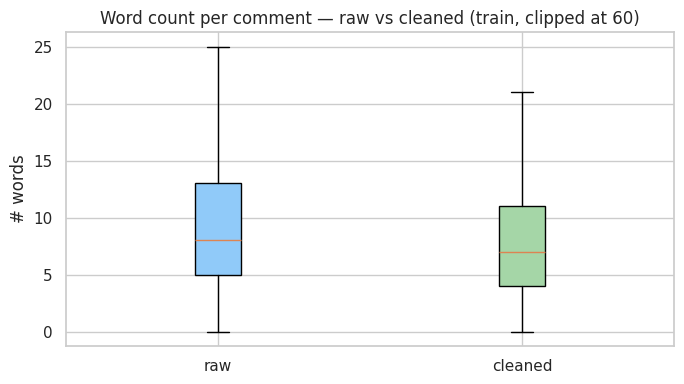

mean words raw     : 11.51
mean words cleaned : 9.72


In [5]:
train['n_words_raw']   = train[TEXT].fillna('').astype(str).str.split().map(len)
train['n_words_clean'] = train['cleaned'].fillna('').str.split().map(len)

fig, ax = plt.subplots(figsize=(7, 4))
data = [
    train['n_words_raw'].clip(upper=60),
    train['n_words_clean'].clip(upper=60),
]
bp = ax.boxplot(data, labels=['raw', 'cleaned'], patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['#90CAF9', '#A5D6A7']):
    patch.set_facecolor(color)
ax.set_ylabel('# words')
ax.set_title('Word count per comment — raw vs cleaned (train, clipped at 60)')
plt.tight_layout()
plt.show()

print(f"mean words raw     : {train['n_words_raw'].mean():.2f}")
print(f"mean words cleaned : {train['n_words_clean'].mean():.2f}")

In [6]:
n_empty = (train['cleaned'].fillna('').str.strip() == '').sum()
pct_empty = n_empty / len(train) * 100
print(f'Empty after cleaning: {n_empty} / {len(train)} ({pct_empty:.2f}%)')
if pct_empty > 1:
    print('WARNING: more than 1% of comments became empty — inspect the regex rules.')
else:
    print('OK — empty rate within acceptable threshold.')

train[train['cleaned'].fillna('').str.strip() == ''][[TEXT, LABEL]].head(10)

Empty after cleaning: 234 / 24048 (0.97%)
OK — empty rate within acceptable threshold.


,free_text,label_id
8,🥰🥰🥰,0
103,😞,0
144,🙆🏻‍♀️,0
214,:)),0
242,.,0
248,🤣🤣🤣,0
275,",..",0
299,🙃,0
413,"<(\"")",0
592,😜😂😂,0


## 4. Stop-word analysis (technical decision)

Question: should we **strip Vietnamese stop-words** before vectorising?

Hate-speech and offensive comments often depend on negation and intensifiers (`không`, `đừng`, `rất`, `quá`, ...). Many of these are present in standard Vietnamese stop-word lists, but they carry strong signal here. We inspect the top tokens of the HATE class to decide.

In [7]:
# A reasonably standard Vietnamese stop-word list (subset).
VI_STOPWORDS = set('''
và là của có không được trong cho với từ một các những này đó đây thì mà nếu
tôi bạn nó họ mình ta chúng ấy ai gì sao vì để đã đang sẽ rất quá lắm vẫn còn
ở khi tại cũng nên hay hoặc nhưng bị bởi cùng mỗi nhiều ít chỉ thôi à ạ ơi nhé
ra vào về trên dưới giữa bên cái con thằng thế nha nhỉ đừng phải
'''.split())
len(VI_STOPWORDS)

75

In [8]:
hate_tokens = collections.Counter()
for txt in train.loc[train[LABEL] == 2, 'cleaned']:
    hate_tokens.update(txt.split())

top30 = hate_tokens.most_common(30)
df_top = pd.DataFrame(top30, columns=['token', 'count'])
df_top['is_stopword']  = df_top['token'].isin(VI_STOPWORDS)
df_top['emotion_word'] = df_top['token'].isin({'không', 'đừng', 'rất', 'quá', 'thì', 'mà'})
df_top

,token,count,is_stopword,emotion_word
0,không,715,True,True
1,là,631,True,False
2,có,592,True,False
3,con,497,True,False
4,nó,465,True,False
5,cái,458,True,False
6,mà,449,True,True
7,thì,428,True,True
8,cho,426,True,False
9,này,361,True,False


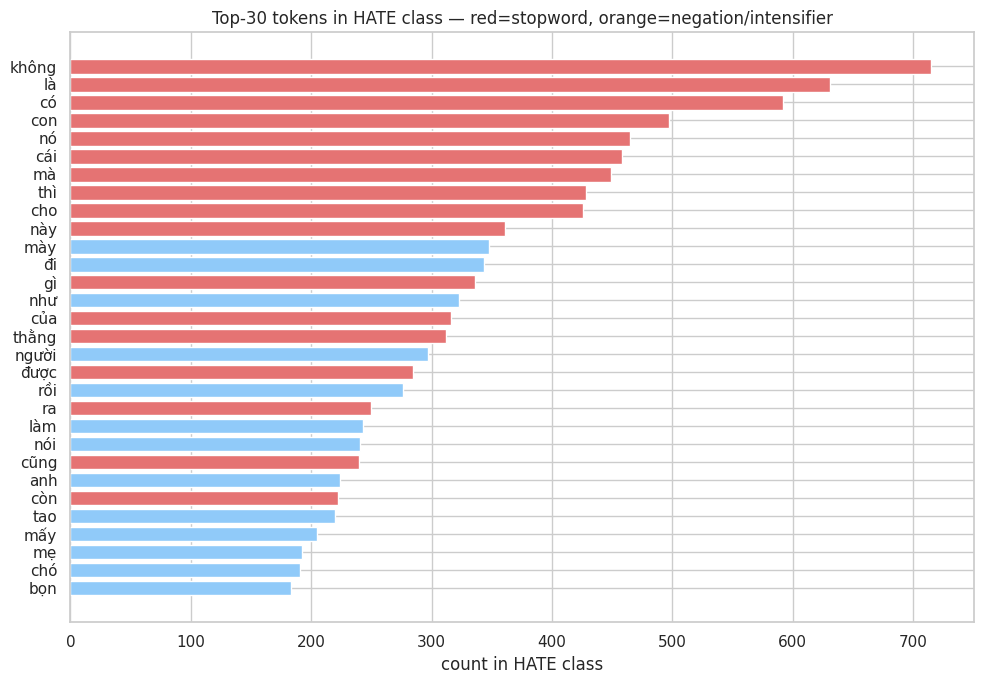

17 of the top-30 HATE tokens overlap with stop-word list:
['không', 'là', 'có', 'con', 'nó', 'cái', 'mà', 'thì', 'cho', 'này', 'gì', 'của', 'thằng', 'được', 'ra', 'cũng', 'còn']


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = [
    '#E57373' if sw else ('#FFB74D' if em else '#90CAF9')
    for sw, em in zip(df_top['is_stopword'], df_top['emotion_word'])
]
ax.barh(df_top['token'], df_top['count'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('count in HATE class')
ax.set_title('Top-30 tokens in HATE class — red=stopword, orange=negation/intensifier')
plt.tight_layout()
plt.show()

overlap = df_top[df_top['is_stopword']]['token'].tolist()
print(f'{len(overlap)} of the top-30 HATE tokens overlap with stop-word list:')
print(overlap)

### Decision: **KEEP stop-words**

Reasons:

1. Standard Vietnamese stop-word lists include negation/intensifier words (`không`, `đừng`, `rất`, `quá`) that flip or amplify the meaning of an attack — exactly what we are trying to detect.
2. Several of the top-30 HATE tokens are stop-words. Removing them would discard real signal.
3. TF-IDF + `min_df` already down-weights generic high-frequency tokens, so we get most of the benefit of stop-word filtering without losing semantically loaded words.
4. We can revisit this as an ablation in Week 3 if the baseline under-performs.

## 5. Fit vectorizers & save

In [10]:
dev_clean  = batch_clean(dev[TEXT],  cleaner=cleaner, desc='Cleaning dev')
test_clean = batch_clean(test[TEXT], cleaner=cleaner, desc='Cleaning test')

texts_dict  = {'train': train_clean, 'dev': dev_clean, 'test': test_clean}
labels_dict = {
    'train': train[LABEL].astype(int),
    'dev':   dev[LABEL].astype(int),
    'test':  test[LABEL].astype(int),
}

Cleaning dev:   0%|          | 0/2672 [00:00<?, ?it/s]

Cleaning test:   0%|          | 0/6680 [00:00<?, ?it/s]

In [11]:
vectorizers = fit_vectorizers(texts_dict['train'])
transform_and_save(vectorizers, texts_dict, labels_dict)

Fitting vectorizers:   0%|          | 0/3 [00:00<?, ?it/s]

  [bow] vocab size=8,749  →  /home/user/Graduation-Project/models/vectorizers/bow.pkl


  [tfidf_uni] vocab size=8,749  →  /home/user/Graduation-Project/models/vectorizers/tfidf_uni.pkl


  [tfidf_unibi] vocab size=10,000  →  /home/user/Graduation-Project/models/vectorizers/tfidf_unibi.pkl
  [y_train]  shape=(24048,)  →  /home/user/Graduation-Project/data/processed/y_train.npy


  [X_train_bow]  shape=(24048, 8749)  nnz=195,683  →  /home/user/Graduation-Project/data/processed/X_train_bow.npz


  [X_train_tfidf_uni]  shape=(24048, 8749)  nnz=195,683  →  /home/user/Graduation-Project/data/processed/X_train_tfidf_uni.npz


  [X_train_tfidf_unibi]  shape=(24048, 10000)  nnz=243,929  →  /home/user/Graduation-Project/data/processed/X_train_tfidf_unibi.npz
  [y_dev]  shape=(2672,)  →  /home/user/Graduation-Project/data/processed/y_dev.npy
  [X_dev_bow]  shape=(2672, 8749)  nnz=21,146  →  /home/user/Graduation-Project/data/processed/X_dev_bow.npz
  [X_dev_tfidf_uni]  shape=(2672, 8749)  nnz=21,146  →  /home/user/Graduation-Project/data/processed/X_dev_tfidf_uni.npz
  [X_dev_tfidf_unibi]  shape=(2672, 10000)  nnz=26,011  →  /home/user/Graduation-Project/data/processed/X_dev_tfidf_unibi.npz
  [y_test]  shape=(6680,)  →  /home/user/Graduation-Project/data/processed/y_test.npy


  [X_test_bow]  shape=(6680, 8749)  nnz=52,979  →  /home/user/Graduation-Project/data/processed/X_test_bow.npz
  [X_test_tfidf_uni]  shape=(6680, 8749)  nnz=52,979  →  /home/user/Graduation-Project/data/processed/X_test_tfidf_uni.npz


  [X_test_tfidf_unibi]  shape=(6680, 10000)  nnz=65,313  →  /home/user/Graduation-Project/data/processed/X_test_tfidf_unibi.npz


In [12]:
# Quick shape verification — uses the loader from src/features
import scipy.sparse as sp
rows = []
for split in ('train', 'dev', 'test'):
    for feat in ('bow', 'tfidf_uni', 'tfidf_unibi'):
        X, y = load_feature_matrix(split, feat)
        rows.append({'split': split, 'feature': feat,
                     'rows': X.shape[0], 'cols': X.shape[1], 'nnz': X.nnz})
pd.DataFrame(rows)

,split,feature,rows,cols,nnz
0,train,bow,24048,8749,195683
1,train,tfidf_uni,24048,8749,195683
2,train,tfidf_unibi,24048,10000,243929
3,dev,bow,2672,8749,21146
4,dev,tfidf_uni,2672,8749,21146
5,dev,tfidf_unibi,2672,10000,26011
6,test,bow,6680,8749,52979
7,test,tfidf_uni,6680,8749,52979
8,test,tfidf_unibi,6680,10000,65313


### Top features by class (TF-IDF unigram)

For each label, compute the **mean TF-IDF** of every vocabulary term over the comments in that class, then take the 20 largest. These are the words most characteristic of each class according to TF-IDF — useful as a sanity-check before training.

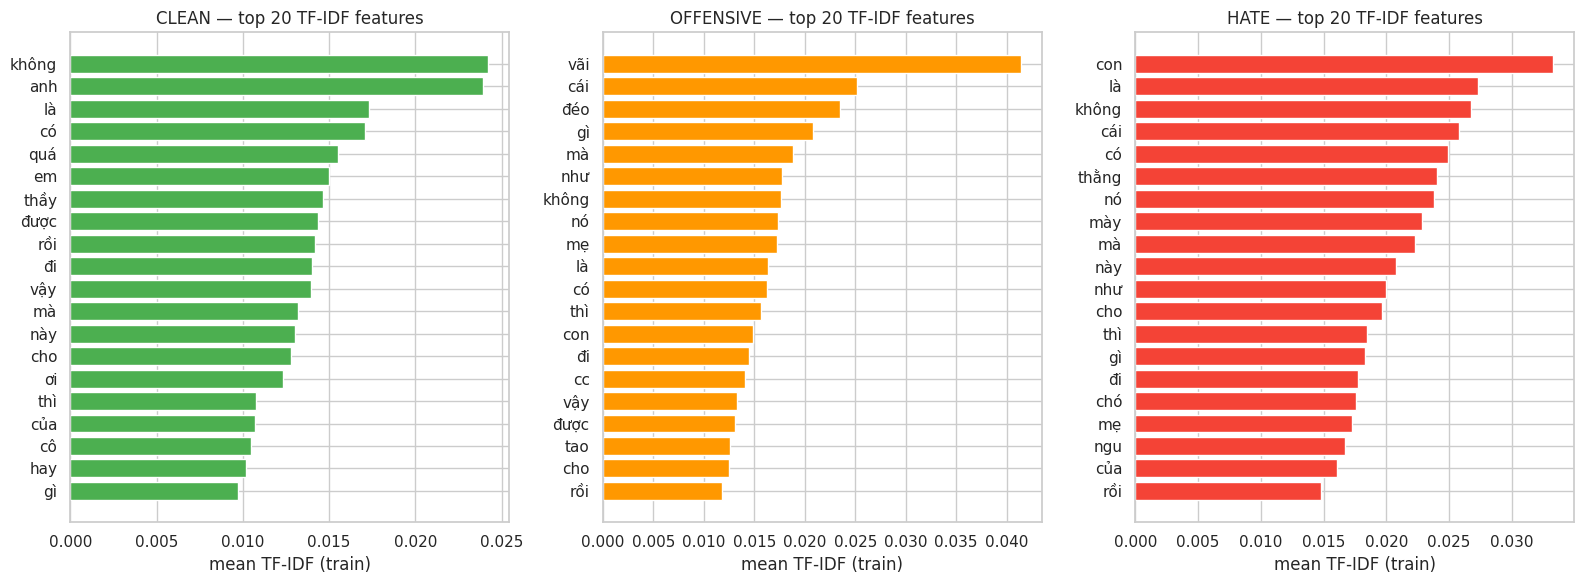

In [13]:
X_train, y_train = load_feature_matrix('train', 'tfidf_uni')
vocab = np.array(vectorizers['tfidf_uni'].get_feature_names_out())

TOP_N = 20
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, lid in zip(axes, sorted(LABEL_MAP)):
    mask = (y_train == lid)
    mean_tfidf = np.asarray(X_train[mask].mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[-TOP_N:][::-1]
    ax.barh(vocab[top_idx][::-1], mean_tfidf[top_idx][::-1],
            color=LABEL_COLORS[lid])
    ax.set_title(f'{LABEL_MAP[lid]} — top {TOP_N} TF-IDF features')
    ax.set_xlabel('mean TF-IDF (train)')
plt.tight_layout()
plt.savefig(Path(PATHS['figures_dir']) / 'top_tfidf_per_label.png', bbox_inches='tight')
plt.show()

## 6. Verify a saved vectorizer can be reloaded

In [14]:
loaded = load_vectorizers()
list(loaded.keys())

['bow', 'tfidf_uni', 'tfidf_unibi']

In [15]:
new_sentence = 'đm thằng này ngu vl'
cleaned_new  = cleaner.clean(new_sentence)
print('raw     :', new_sentence)
print('cleaned :', cleaned_new)

X_new = loaded['tfidf_unibi'].transform([cleaned_new])
vocab = np.array(loaded['tfidf_unibi'].get_feature_names_out())

nz_idx = X_new.nonzero()[1]
scores = np.asarray(X_new[0, nz_idx].todense()).ravel()
order  = scores.argsort()[::-1]

pd.DataFrame({
    'token':  vocab[nz_idx][order],
    'tfidf':  scores[order].round(4),
})

raw     : đm thằng này ngu vl
cleaned : đm thằng này ngu vãi


,token,tfidf
0,đm thằng,0.5090
1,ngu vãi,0.4433
2,thằng này,0.4061
3,đm,0.3341
4,ngu,0.3048
5,thằng,0.2654
6,vãi,0.2552
7,này,0.1984


### Why this matters

We can reconstruct the **exact same vocabulary mapping** at inference time without retraining. This is what `src/predict.py` and the FastAPI/Streamlit app will rely on in later weeks.

## ✅ Week-2 checklist

- [x] `VietnameseTextCleaner` validated on stratified samples.
- [x] Pipeline applied to all of train (no >1% empty after cleaning).
- [x] Stop-word policy: **keep** (justified by HATE-class token analysis).
- [x] Three vectorizers fitted on train and persisted.
- [x] Feature matrices saved for all splits.
- [x] Reload-and-transform sanity check passes.

Ready for **Week 3 — train ML baselines** (`notebooks/03_baseline_ml.ipynb`):
Logistic Regression and Linear SVM on the three feature sets, evaluated with macro-F1 and per-class F1.